# General
Template for labjournaal. See https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html for options to use markdown.

**Name:**  Lukas Calixtro & Oskar van Velze  
**Title of the experiment:**  Een benadering van de invloed van valsnelheid op het verschil tussen ideale en non-ideale val
**Starting date:**  09/01/26  
**Expected enddate:**  23/01/26   
**Goal of the experiment:**  Bepalen welke invloed verliezen m.b.t. de valsnelheid hebben op de val van waterdruppels
**Research question:**  Wat is het effect van de valsnelheid op de afweiking tussen de ideale en non-ideale val
**Expectations or Hypothesis:**  Hoe groter de snelheid hoe groter het verschil. Wij verwachten ook dat de weerstand zal toenemen met snelheid.
**Desired accuracy:**  >50%




In [88]:
#import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.optimize import curve_fit 

# Preparation
 


**Assignments:**  



Het doel van dit onderzoek om de verliezen, van voornamelijk de wrijving, te benaderen door te meten aan een vallende waterdruppel. Door van verschillende valhoogtes te meten bereiken de waterdruppels verschillende snelheden, vervolgens wordt deze data vergeleken met de theoretische waardes.

**Method:**  
**Theory:**  
**Independent variable:**  
1. Valhoogte  

**Dependent variable:**  
1. Valtijd  

**Controlled variablen:**  
1. Vorm en grootte van druppel
2. Valversnelling  

In dit experiment wordt geprobeerd om de relatie tussen de valsnelheid en het verschil van ideale en non-ideale val aan te tonen. Dit wordt gedaan door gebruik
te maken van de standaard opstelling die getoond wordt in beide figuur 14.8
van de handleiding en hier rechts. Waarbij de bovenste detector wordt
geplaatst net onder de pipet, met markeringen v0=s0=t0=0 en de detector
onder, net boven de grond. De hoogte wordt gevariëerd om de druppels op verschillende snelheden te krijgen. Metingen op elke hoogte worden 10 keer herhaald, waar vervolgens het gemiddelde van wordt gepakt. De gemiddelde meting wordt vervolgens gebruikt om $\beta$ te fitten. Daarmee wordt de bereikte snelheid berekend, welke vervolgens wordt vergeleken met het theoretische model voor een ideale val.

**Measurement instruments \& Settings:**  

Standaard pipet, twee optische sensoren met fotoreceptoren, timer, camera op 70x1.5mm - ISO 1000 - 1/320 - f/8.0, vari-snelheid luchtblazer.

**Procedure:**  

Dezelfde persoon doet elke meting om verschil in druppels te minimaliseren. Het meetinstrument wordt na elke meting uit en aan gezet om de timer te resetten.

**Setup(drawing or picture):**  

Standaard meetopstelling voor val met wrijving.


# Execution

In [89]:
rho_water = 998.2       #Dichtheid van water (kg.m^-3)
rho_lucht = 1.225       #Dichtheid van lucht (kg.m^-3)
g = 9.812               #Valversnelling (m/s^-2)


In [90]:
#Raw Data
Data = np.loadtxt('Raw_ValWrijving.csv',delimiter=';', skiprows=1)      #Data importeren

**Observations:**  
- Een grotere valhoogte zorgde voor een een steeds grotere valtijd, wat volgens verwachtingen is.
- Tijdens het meten, miste de druppel soms de tweede sensor, deze gevallen werden verder genegeerd.
- Wanneer een druppel op een verschillende manier uit het pipet druppelt, ontstaat een klein verschil in de valtijd. Hierom werd er voor gezorgd dat ieder druppel op dezelfde manier eruit druppelde.

**Notes:**  
- Onzekerheid groot meetlint: ?
- Onzekerheid sensoren: 0.005s
- Onzekerheid (?): ?

# Processing
**Description of processing of raw data into scientific evidence:**


<function matplotlib.pyplot.show(close=None, block=None)>

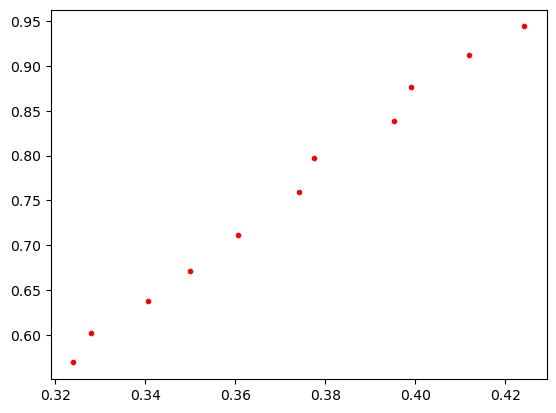

In [98]:
#Data processing and analysis:

Hoogte_Data = Data[:,0]    #Valhoogte (m)
u_Hoogte = 0.005         #Onzekerheid valhoogte (m)

#Alle 10 valtijd metingen per hoogte (s)
Val_Data1 = Data[0,1:]
Val_Data2 = Data[1,1:]
Val_Data3 = Data[2,1:]
Val_Data4 = Data[3,1:]
Val_Data5 = Data[4,1:]
Val_Data6 = Data[5,1:]
Val_Data7 = Data[6,1:]
Val_Data8 = Data[7,1:]
Val_Data9 = Data[8,1:]
Val_Data10 = Data[9,1:]
Val_Data11 = Data[10,1:]

#Gemiddelde valtijd per hoogte (s)
Val_tijd1 = np.mean(Val_Data1)
Val_tijd2 = np.mean(Val_Data2)
Val_tijd3 = np.mean(Val_Data3)
Val_tijd4 = np.mean(Val_Data4)
Val_tijd5 = np.mean(Val_Data5)
Val_tijd6 = np.mean(Val_Data6)
Val_tijd7 = np.mean(Val_Data7)
Val_tijd8 = np.mean(Val_Data8)
Val_tijd9 = np.mean(Val_Data9)
Val_tijd10 = np.mean(Val_Data10)
Val_tijd11 = np.mean(Val_Data11)
 

Val_tijden = np.array([Val_tijd1, Val_tijd2, Val_tijd3, Val_tijd4, Val_tijd5, Val_tijd6, Val_tijd7, Val_tijd8, Val_tijd9, Val_tijd10, Val_tijd11])
u_tijden = 0.0005   #Onzekerheid valtijd (s)

#Test plot
plt.figure()
plt.plot(Val_tijden, Hoogte_Data, 'r.')
plt.show



In [92]:
#Data processing and analysis:
L_naald = 0.0105 #Daadwerkelijke lengte van naald (m)

#Diameters zijn berekend met behulp van Fiji-software en schaal van L_naald
#Aangenomen dat alle druppels perfect bolvormig zijn, ook al zijn ze dat in de fotos niet helemaal
#Uit de fotos afgeleide diameters (m)
D_druppel1 = 0.003875 
D_druppel2 = 0.003993 
D_druppel3 = 0.003888

#Straal van druppels (m)
R_druppel1 = D_druppel1/2
R_druppel2 = D_druppel2/2
R_druppel3 = D_druppel3/2

#Volume van druppels (m^3)
#Aangenomen dat druppels perfect bolvormig zijn
V_druppel1 = (4/3)*np.pi*R_druppel1**3
V_druppel2 = (4/3)*np.pi*R_druppel2**3
V_druppel3 = (4/3)*np.pi*R_druppel3**3

#Massa van druppels (kg)
m_druppel1 = rho_water*V_druppel1
m_druppel2 = rho_water*V_druppel2
m_druppel3 = rho_water*V_druppel3

**Describing the pattern in the processed data:**  


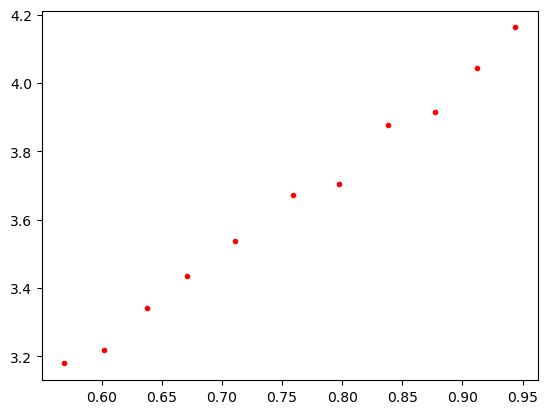

In [93]:
#Ideale val: zonder wrijving    
v_ideal = g * Val_tijden    
u_v_ideal = g * u_tijden                #Ideale valsnelheid zonder wrijving (m/s)    

plt.figure()
plt.plot(Hoogte_Data, v_ideal, 'r.')
plt.show()

$$
    \frac{1}{2}gt^2 - s(t) = \frac{\beta g^2}{12m}t^4 
    \rightarrow 
    s(t) = \frac{1}{2}gt^2 - \frac{\beta g^2}{12m}t^4

    $$


In [94]:
#Beta vinden
def s_func(t, beta):
    return 0.5 * g * t**2 - (beta / (12 * m_druppel1)) * g**2 * t**4

popt, pcov = curve_fit(s_func, Hoogte_Data, Val_tijden)
beta_fit = popt[0]
u_beta_fit = np.sqrt(np.diag(pcov))[0]

print("Beta fit:", beta_fit)
print("Uncertainty in Beta fit:", u_beta_fit)

Beta fit: 2.2359138362820818e-05
Uncertainty in Beta fit: 1.482099553866522e-06


Met de gevonden $\beta$:

$$
    v(t) = v_0 + gt - \frac{1}{3}\frac{\beta}{m}g^2t^3
    $$

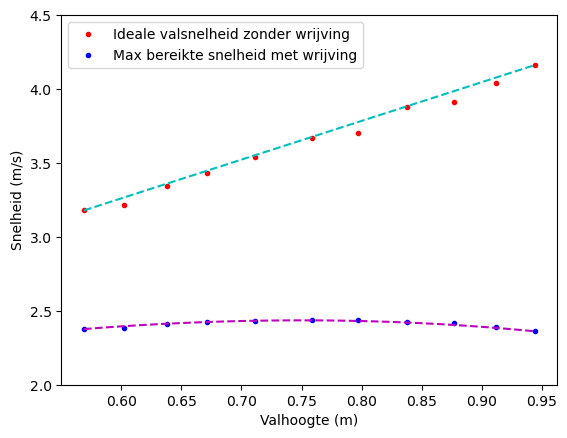

In [108]:
#Bereken max bereikte snelheid
def v_func(t, beta):
    return g * t - 1/3 * (beta / m_druppel1) * g**2 * t**3

v_wrijving = v_func(Val_tijden, beta_fit)
u_v_wrijving = np.sqrt(((g - beta_fit/m_druppel1 * g**2 * Val_tijden**2)**2 * (u_tijden)**2) + (((g**2 * Val_tijden**3)/(3 * m_druppel1))**2 * (u_beta_fit)**2))
#Fitten
H_fit = np.linspace(min(Hoogte_Data), max(Hoogte_Data), 100)

#Fit ideale snelheden
t_fit = np.linspace(min(Val_tijden), max(Val_tijden), 100)
ideal_fit = g * t_fit

#Fit met wrijving
v_fit = v_func(t_fit, beta_fit)


#Plot van ideal en berekende max snelheid
plt.figure()
plt.plot(Hoogte_Data, v_ideal, 'r.', label='Ideale valsnelheid zonder wrijving')
plt.plot(H_fit, ideal_fit, 'c--')
plt.plot(Hoogte_Data, v_wrijving, 'b.', label='Max bereikte snelheid met wrijving')
plt.plot(H_fit, v_fit, 'm--')
plt.ylim(2, 4.5)
plt.xlabel('Valhoogte (m)')
plt.ylabel('Snelheid (m/s)')
plt.legend()
plt.show()

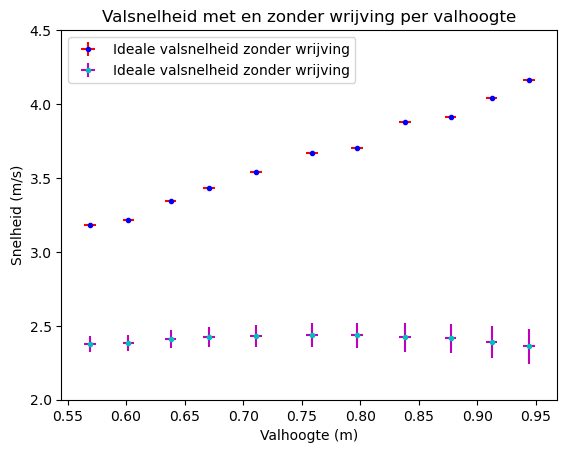

In [115]:
plt.figure()
plt.title('Valsnelheid met en zonder wrijving per valhoogte')
plt.errorbar(Hoogte_Data, v_ideal, xerr=u_Hoogte, yerr=u_v_ideal, fmt='.',color='b',ecolor='r', label='Ideale valsnelheid zonder wrijving',)
plt.errorbar(Hoogte_Data, v_wrijving, xerr=u_Hoogte, yerr=u_v_wrijving, fmt='.',color="c",ecolor="m", label='Ideale valsnelheid zonder wrijving')
plt.ylim(2, 4.5)
plt.xlabel('Valhoogte (m)')
plt.ylabel('Snelheid (m/s)')
plt.legend()
plt.savefig('ValsnelheidPerHoogte.jpg', dpi = 300, bbox_inches='tight')
plt.show()


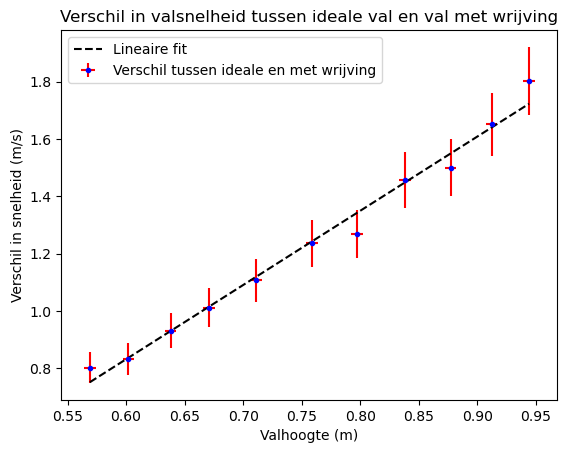

In [121]:
#Verschil tussen ideale en met wrijving
delta_V = v_ideal - v_wrijving
u_delta_V = np.sqrt(u_v_ideal**2 + u_v_wrijving**2)

#Check of linear is
def lin_func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(lin_func, Hoogte_Data, delta_V, p0=[(delta_V[-1] - delta_V[0])/(Hoogte_Data[-1] - Hoogte_Data[0]), delta_V[0]])
a_fit = popt[0]
b_fit = popt[1]
u_a_fit = np.sqrt(np.diag(pcov))[0]
u_b_fit = np.sqrt(np.diag(pcov))[1]

plt.figure()
plt.title('Verschil in valsnelheid tussen ideale val en val met wrijving')
plt.errorbar(Hoogte_Data, delta_V, xerr=u_Hoogte, yerr=u_delta_V, fmt='.', color='b', ecolor='r', label='Verschil tussen ideale en met wrijving')
plt.plot(H_fit, lin_func(H_fit, a_fit, b_fit), 'k--', label='Lineaire fit')
plt.xlabel('Valhoogte (m)')
plt.ylabel('Verschil in snelheid (m/s)')
plt.legend()
plt.savefig('VerschilSsnelheid.jpg', dpi = 300, bbox_inches='tight')
plt.show()

**Notes:**  

# Discussion



# Conclusion

# Additional notes, remarks, explanations, thoughts etc